In [206]:
from sys import displayhook
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [207]:
import pandas as pd
import numpy as np
import seaborn as sns

In [208]:
dataframe = pd.read_csv("test_data.csv", index_col=0)
print(dataframe)

                            File   Status    Runtime  Runlength  quality  seed
0       ./storage/default7/1.txt    UNSAT   966.8330          0        0    -1
1       ./storage/default7/4.txt    UNSAT   178.4680          0        0    -1
2       ./storage/default7/5.txt    UNSAT    85.3295          0        0    -1
3       ./storage/default7/6.txt    UNSAT  1647.0200          0        0    -1
4       ./storage/default7/7.txt    UNSAT  1521.0100          0        0    -1
..                           ...      ...        ...        ...      ...   ...
178  ./storage/default7/1856.txt  SUCCESS    36.2545          0        0    -1
179  ./storage/default7/1857.txt  SUCCESS  2084.8800          0        0    -1
180  ./storage/default7/1858.txt  SUCCESS   371.6770          0        0    -1
181  ./storage/default7/1869.txt  SUCCESS   149.1110          0        0    -1
182  ./storage/default7/1881.txt  SUCCESS    32.7798          0        0    -1

[183 rows x 6 columns]


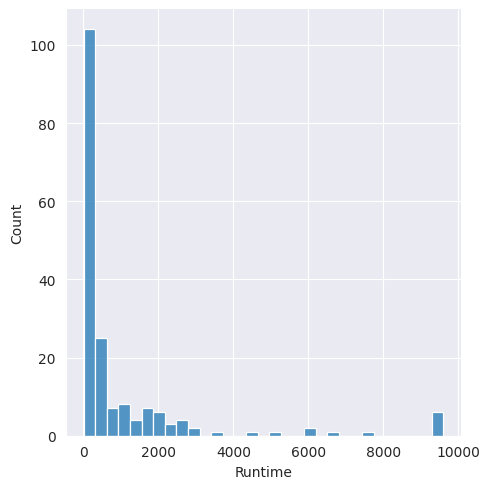

In [209]:
sns.displot(dataframe, x="Runtime")

In [210]:
print(dataframe["Runtime"].describe())

count     183.000000
mean     1025.037449
std      2011.007322
min         5.529900
25%        53.959500
50%       227.589000
75%       958.073500
max      9601.170000
Name: Runtime, dtype: float64


How about we optimize over everything above mean

In [211]:
print(dataframe["Status"].value_counts())

Status
SUCCESS    130
UNSAT       47
TIMEOUT      6
Name: count, dtype: int64


# Splitting test and training

In [212]:
train = []

with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/training.txt") as file:
    line = file.readline()
    while line:
        number = line.split("/")[-1][4:-4]
        train.append(f"./storage/default7/{number}.txt")
        # print(number)
        # print(line.strip())
        line = file.readline()
    file.close()

print(train)
train_dataframe = dataframe[dataframe["File"].isin(train)]
display(train_dataframe)

['./storage/default7/1.txt', './storage/default7/4.txt', './storage/default7/5.txt', './storage/default7/6.txt', './storage/default7/7.txt', './storage/default7/11.txt', './storage/default7/12.txt', './storage/default7/13.txt', './storage/default7/14.txt', './storage/default7/15.txt', './storage/default7/18.txt', './storage/default7/20.txt', './storage/default7/21.txt', './storage/default7/22.txt', './storage/default7/23.txt', './storage/default7/24.txt', './storage/default7/26.txt', './storage/default7/27.txt', './storage/default7/28.txt', './storage/default7/29.txt', './storage/default7/30.txt', './storage/default7/31.txt', './storage/default7/32.txt', './storage/default7/33.txt', './storage/default7/35.txt', './storage/default7/34.txt', './storage/default7/63.txt', './storage/default7/64.txt', './storage/default7/93.txt', './storage/default7/116.txt', './storage/default7/120.txt', './storage/default7/134.txt', './storage/default7/145.txt', './storage/default7/152.txt', './storage/de

,File,Status,Runtime,Runlength,quality,seed
0,./storage/default7/1.txt,UNSAT,966.8330,0,0,-1
1,./storage/default7/4.txt,UNSAT,178.4680,0,0,-1
2,./storage/default7/5.txt,UNSAT,85.3295,0,0,-1
3,./storage/default7/6.txt,UNSAT,1647.0200,0,0,-1
4,./storage/default7/7.txt,UNSAT,1521.0100,0,0,-1
...,...,...,...,...,...,...
112,./storage/default7/884.txt,SUCCESS,114.2630,0,0,-1
113,./storage/default7/891.txt,SUCCESS,71.0128,0,0,-1
114,./storage/default7/899.txt,SUCCESS,22.6034,0,0,-1
115,./storage/default7/901.txt,SUCCESS,1290.0000,0,0,-1


count      92.000000
mean     1148.551835
std      2089.521849
min         6.082770
25%        55.294725
50%       243.361500
75%      1344.075000
max      9601.170000
Name: Runtime, dtype: float64
Status
SUCCESS    66
UNSAT      23
TIMEOUT     3
Name: count, dtype: int64


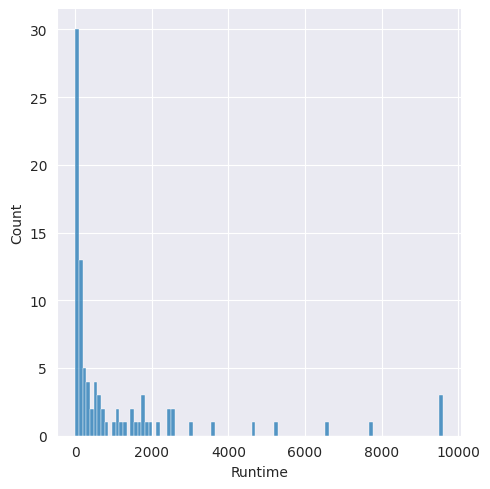

In [213]:
sns.displot(train_dataframe, x="Runtime", bins=100)
print(train_dataframe["Runtime"].describe())
print(train_dataframe["Status"].value_counts())

This kinda makes me think we can get away with optimizing with a WAAYYYYY lower capped runtime like 40_000 without actually losing much....
But again this could be because of default, but it's the standard we're trying to beat, so in that regard it wouln't matter.

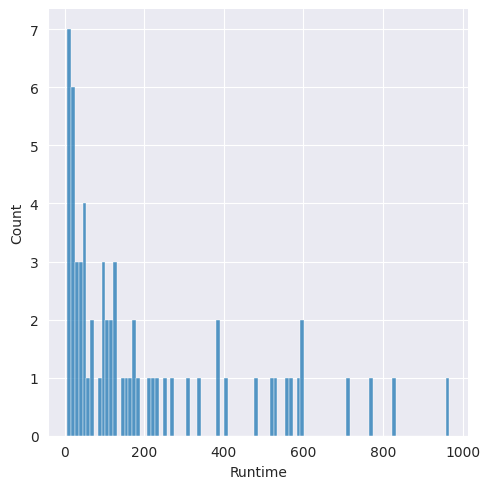

In [214]:
sns.displot(train_dataframe[train_dataframe["Runtime"] < 1000], x="Runtime", bins=100)


### Test examples

In [215]:
test = []

with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/test.txt") as file:
    line = file.readline()
    while line:
        number = line.split("/")[-1][4:-4]
        test.append(f"./storage/default7/{number}.txt")
        # print(number)
        # print(line.strip())
        line = file.readline()
    file.close()

print(test)
test_dataframe = dataframe[dataframe["File"].isin(test)]
display(test_dataframe)

['./storage/default7/36.txt', './storage/default7/37.txt', './storage/default7/38.txt', './storage/default7/40.txt', './storage/default7/43.txt', './storage/default7/49.txt', './storage/default7/50.txt', './storage/default7/51.txt', './storage/default7/52.txt', './storage/default7/53.txt', './storage/default7/55.txt', './storage/default7/56.txt', './storage/default7/57.txt', './storage/default7/58.txt', './storage/default7/61.txt', './storage/default7/68.txt', './storage/default7/69.txt', './storage/default7/70.txt', './storage/default7/71.txt', './storage/default7/72.txt', './storage/default7/75.txt', './storage/default7/77.txt', './storage/default7/80.txt', './storage/default7/81.txt', './storage/default7/82.txt', './storage/default7/927.txt', './storage/default7/931.txt', './storage/default7/961.txt', './storage/default7/983.txt', './storage/default7/1018.txt', './storage/default7/1033.txt', './storage/default7/1069.txt', './storage/default7/1073.txt', './storage/default7/1083.txt',

,File,Status,Runtime,Runlength,quality,seed
26,./storage/default7/36.txt,UNSAT,187.3250,0,0,-1
27,./storage/default7/37.txt,UNSAT,540.6040,0,0,-1
28,./storage/default7/38.txt,UNSAT,645.1540,0,0,-1
29,./storage/default7/40.txt,UNSAT,2763.6000,0,0,-1
30,./storage/default7/43.txt,UNSAT,1686.8800,0,0,-1
...,...,...,...,...,...,...
178,./storage/default7/1856.txt,SUCCESS,36.2545,0,0,-1
179,./storage/default7/1857.txt,SUCCESS,2084.8800,0,0,-1
180,./storage/default7/1858.txt,SUCCESS,371.6770,0,0,-1
181,./storage/default7/1869.txt,SUCCESS,149.1110,0,0,-1


count      91.000000
mean      900.165761
std      1931.889256
min         5.529900
25%        53.959500
50%       223.287000
75%       586.660000
max      9601.160000
Name: Runtime, dtype: float64
Status
SUCCESS    64
UNSAT      24
TIMEOUT     3
Name: count, dtype: int64


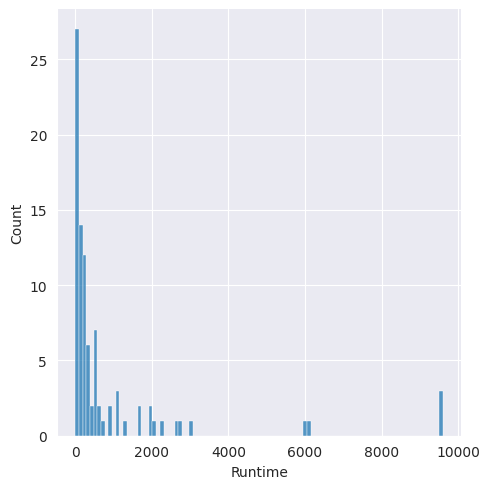

In [216]:
sns.displot(test_dataframe, x="Runtime", bins=100)
print(test_dataframe["Runtime"].describe())
print(test_dataframe["Status"].value_counts())

# Log scale to compare

In [217]:
# TODO: Use log transformed runtime with/without utility? as this is more like a normal distribution
# Hoeffding doesn't assume standard Gaussian but maybe the bounds can be tightend using something like this?

<Axes: xlabel='Runtime', ylabel='Count'>

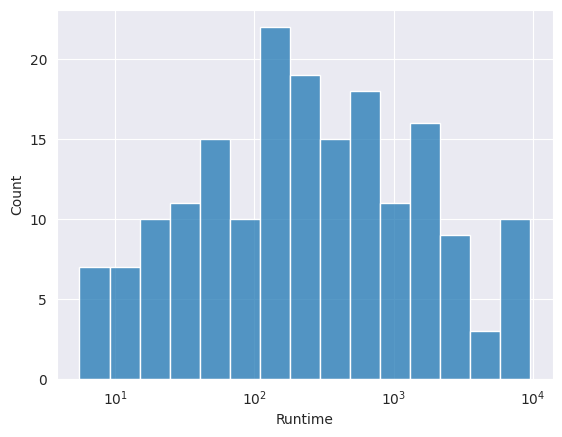

In [218]:
sns.histplot(dataframe, x="Runtime", log_scale=True, bins=15)

How do they have above 9600 in paper? because they use 4 cores for portfolio so 9600 x 4 = 38400, which is also the timeout give to the default for 1 core. default 32 cores get 1200 seconds.
TODO: is PAR10 in the paper an average/distribution? I assume so as they mention binomial test

# Log-laplacian transform

In [219]:
def log_laplace(t, k_0, alpha=1):
    all = []
    for item in t:
        if item < k_0:
            all.append(1 - 0.5* (item/k_0)**alpha)
        else:
            all.append(0.5*(k_0/item)**alpha)
    return np.array(all)

In [220]:
def uniform_util(t, k_0, alpha=1):
    all = []
    for item in t:
        if item < k_0:
            all.append(1 - (item/k_0))
        else:
            all.append(0)
    return np.array(all)

<Axes: >

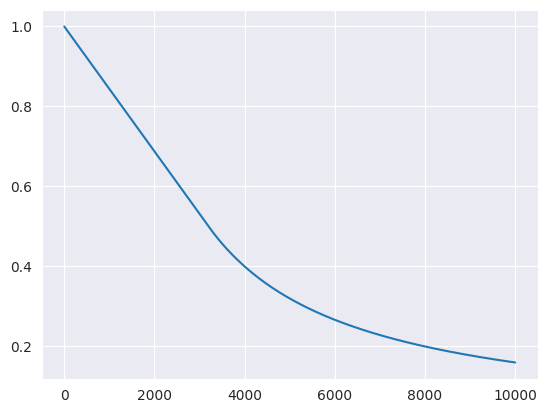

In [221]:
point = np.arange(0, 10_000, 1)
outs = log_laplace(point, 3200)
sns.lineplot(x=point, y=outs)

<Axes: >

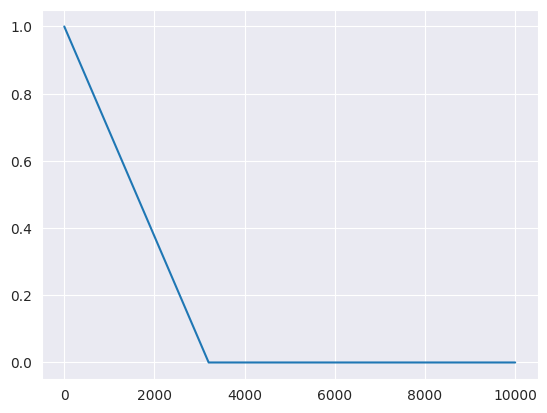

In [222]:
point = np.arange(0, 10_000, 1)
outs = uniform_util(point, 3200)
sns.lineplot(x=point, y=outs)

In [223]:
train_dataframe_copy = train_dataframe.copy(deep=True)

TODO: Why does it use k_0 and if longer then 0, wouldnt that mean doubling the captime doesnt do anything as they get no utility?

Figured it out, untill k_0 is is linear, then after it lowers more slowly, at least for log-laplace (check above)
For uniform I have no clue.

In [224]:
k_0 = 250 #1000

In [225]:
train_dataframe_copy["Utility"] = log_laplace(train_dataframe_copy["Runtime"], k_0=k_0)

Using 1000 here because its the mean, but we could probably do a lot lower, maybe even 250 because 50% of the data is below this, but not a good idea as linear decrease up to this point
But what would we set a k_0, probably 250 and not 1000, because we will double anyway...

Should we aim for a utility function that follows the distribution of the actual samples of the baseline (default)?


<Axes: >

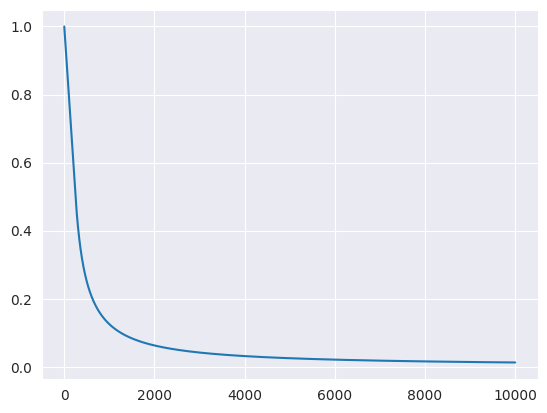

In [226]:
point = np.arange(0, 10_000, 1)
outs = log_laplace(point, k_0=k_0)
sns.lineplot(x=point, y=outs)

count    92.000000
mean      0.492987
std       0.372504
min       0.013019
25%       0.093421
50%       0.513327
75%       0.889411
max       0.987834
Name: Utility, dtype: float64


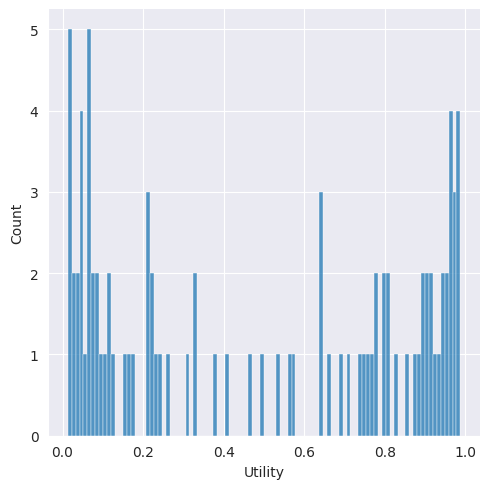

In [227]:
sns.displot(train_dataframe_copy, x="Utility", bins=100)
print(train_dataframe_copy["Utility"].describe())

# Projecting upper and lower confidence bounds by sampling

In [228]:
import random

indices = list(train_dataframe.index)
random.seed(721)
random.shuffle(indices)

# print(indices)

In [229]:
# display(train_dataframe)

In [230]:
def log_laplace_single(t, k_0, alpha=1):
    if t < k_0:
        return 1 - 0.5* (t/k_0)**alpha
    else:
        return 0.5*(k_0/t)**alpha

In [231]:
def uniform_util_single(t, k_0, alpha=1):
        if t < k_0:
            return 1 - (t/k_0)
        else:
            return 0

In [232]:
from COUP_runner import COUP
def bound_plot_data(captime, k_0, dataframe_i, util_func, n_p=1, seed=721, repeats=1):
    indices = list(dataframe_i.index)
    random.seed(seed)
    random.shuffle(indices)
    captime = captime #9600
    k_0 = k_0
    F_hat = [0]
    U_hat = [0]
    UCB = [1]
    LCB = [0]
    n_p = n_p # number of configs only 1 here dunno if this will work..
    m =[0] # n-istanes

    p = 1 # phase 1 # TODO: how does this change when phase increases
    delta= 0.05 # Failure probability?

    for _ in range(repeats):
        for i in indices:
            # print(type(train_dataframe["Runtime"]))
            m.append(m[-1] +1)
            F_hat_i = ((m[-1] - 1) * F_hat[-1] + (1 if dataframe_i["Runtime"][i] < captime else 0)) / m[-1]
            U_hat_i = ((m[-1] - 1) * U_hat[-1] + util_func(dataframe_i["Runtime"][i], k_0)) / m[-1]
            F_hat.append(F_hat_i)
            U_hat.append(U_hat_i)

            alpha_i = COUP.alpha_p(p, n_p, m[-1], captime, delta)
            UCB_i = min(U_hat[-1] + (1 - util_func(captime, k_0)) * alpha_i, UCB[-1])
            LCB_i = max(U_hat[-1] - alpha_i - util_func(captime, k_0) * (1 - F_hat[-1]), LCB[-1])
            UCB.append(UCB_i)
            LCB.append(LCB_i)
    return F_hat, U_hat, UCB, LCB, m

<Axes: >

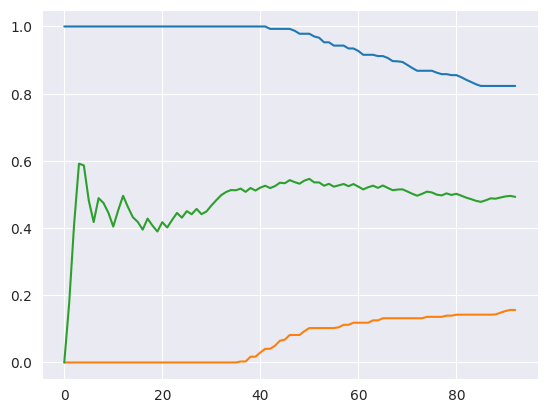

In [233]:
F_hat, U_hat, UCB, LCB, m = bound_plot_data(captime=9600, k_0=250, dataframe_i=train_dataframe, util_func=log_laplace_single)
sns.lineplot(x=m, y=UCB)
sns.lineplot(x=m, y=LCB)
sns.lineplot(x=m, y=U_hat)

<Axes: >

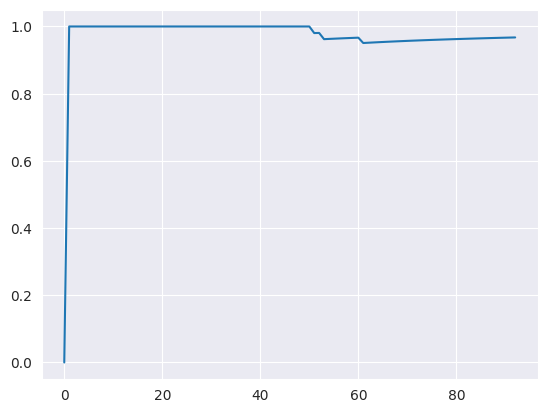

In [234]:
sns.lineplot(x=m, y=F_hat)

### Full data multiple times

In [235]:
print(U_hat[:10])
print(dataframe["Runtime"][indices].head(10))

[0, np.float64(0.17600700648691425), np.float64(0.40950750324345714), np.float64(0.5916748021623047), np.float64(0.5863411016217285), np.float64(0.4821138194103069), np.float64(0.4179113869762894), np.float64(0.4890872459796766), np.float64(0.47483665500146627), np.float64(0.4456386818648229)]
54      710.1990
100     178.4960
79       21.9953
42      214.8300
25     1917.0400
115    1290.0000
53       41.9288
105     333.2600
9       589.4700
56     3648.1000
Name: Runtime, dtype: float64


<Axes: >

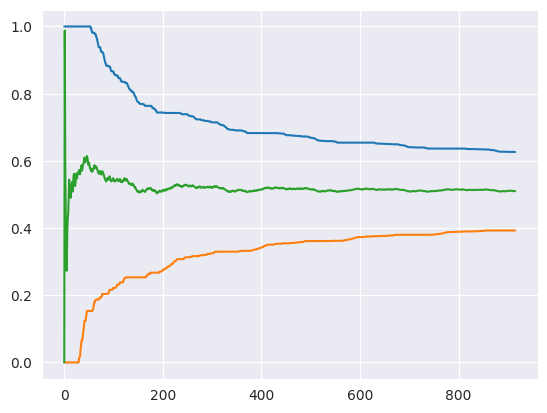

In [236]:
F_hat, U_hat, UCB, LCB, m = bound_plot_data(captime=9600, k_0=250, dataframe_i=dataframe, util_func=log_laplace_single, repeats=5)
sns.lineplot(x=m, y=UCB)
sns.lineplot(x=m, y=LCB)
sns.lineplot(x=m, y=U_hat)

#### Uniform util

<Axes: >

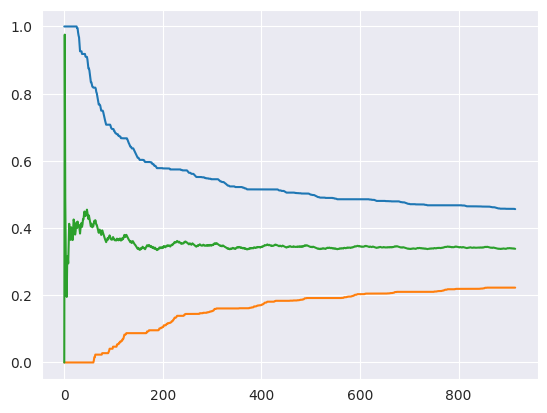

In [237]:
F_hat, U_hat, UCB, LCB, m = bound_plot_data(captime=9600, k_0=250, dataframe_i=dataframe, util_func=uniform_util_single, repeats=5)
sns.lineplot(x=m, y=UCB)
sns.lineplot(x=m, y=LCB)
sns.lineplot(x=m, y=U_hat)

Should be no difference between captime 9600 and captime 250 when k_0=250, because after that no more utility. The only thing is the fraction of timeouts.

<Axes: >

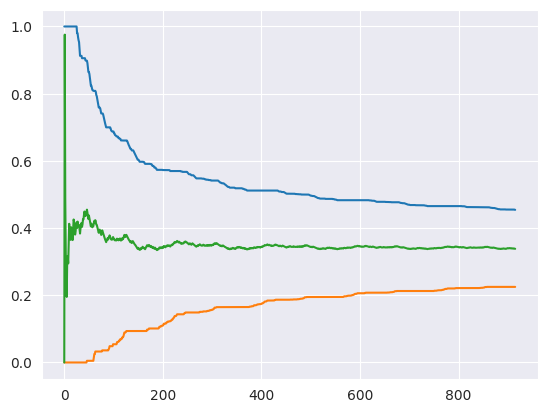

In [238]:
F_hat, U_hat, UCB, LCB, m = bound_plot_data(captime=250, k_0=250, dataframe_i=dataframe, util_func=uniform_util_single, repeats=5)
sns.lineplot(x=m, y=UCB)
sns.lineplot(x=m, y=LCB)
sns.lineplot(x=m, y=U_hat)

<Axes: >

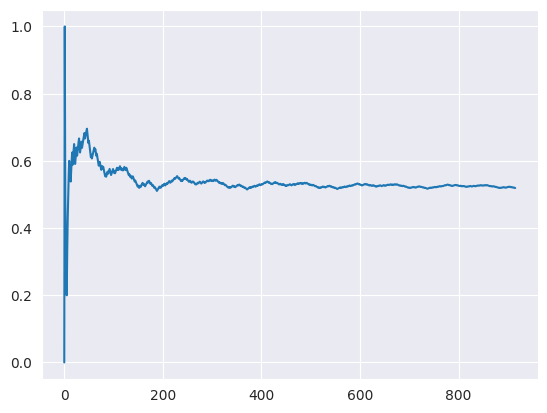

In [239]:
sns.lineplot(x=m, y=F_hat)

<Axes: >

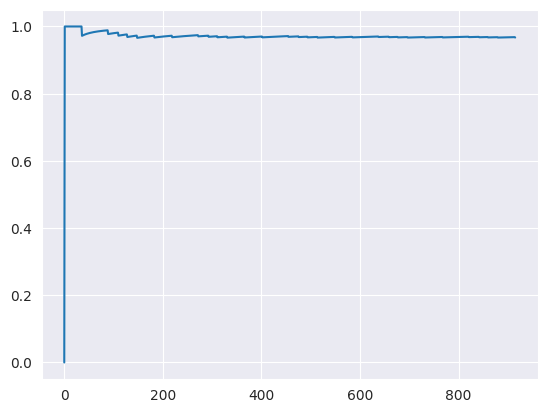

In [240]:
F_hat, U_hat, UCB, LCB, m = bound_plot_data(captime=9600, k_0=250, dataframe_i=dataframe, util_func=uniform_util_single, repeats=5)
sns.lineplot(x=m, y=F_hat)

The meas seems good, but the boiunds really need at least 100 samples to even be slightly tight, meaning that the 92 used now is not enough probably....
How could we make the bounds tighten more quickly? and would we even want to? \
How could we make this into a multi-objective problem, if we aim to make it a portfolio solver? \
Could BO work here? because these bounds are nowhere near tight enough for high dimenional BO probably, but the means is quite good. \

When captime is equal to k_0 the UCB is much faster but the LCB much slower

In [241]:
# TODO: F_hat might actually be a fun objective to use for multi-objective? In PARk score most of the score is also dominated by timeouts right?
# print(dataframe["Runtime"][indices